In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup & parameters

In [26]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from phd_project.scripts.mechanism_identification import identify_soft_storey_mechanism
from phd_project.scripts.loading_protocols import FEMA_461_loading_protocol
from phd_project.scripts.templates.copy_templates_to_folders import (
    copy_structural_model,
    copy_analysis_config,
    configure_batch_run_file,
    copy_file,
)
from phd_project.config import config

cfg = config.load_config()

# --- data location ---
ROOT = Path(r"D:\04_site_influence_investigation")
DEST_ROOT = ROOT

# --- algorithm thresholds (drift primary, brace confirms) ---
DRIFT_CONCENTRATION_FRAC = 0.5  # storey is a candidate if peak drift >= FRAC * max storey drift
FRACTURE_THRESHOLD = 0.30   # brace residual capacity below this = fractured
BRACE_CONFIRM_FRAC = 0.5    # fraction of a storey's braces that must be fractured to confirm
TAIL_FRAC = 0.25            # late-cycle window for the fracture metric

# --- caching (loading the ~300-460 MB pickles is slow; cache results) ---
CACHE_PATH = cfg["proc_data"]["site_specific_3s_mdof_mechanisms"]
FORCE_RECOMPUTE = False

# --- diagnostic-plot palette (color by job, not identity) ---
ACCENT = "#c1121f"    # reserved highlight: soft storey / fractured brace
NEUTRAL = "#9aa0a6"   # everything else
INK = "#222222"

folders = [
    p / "mdof" for p in sorted(ROOT.iterdir())
    if p.is_dir()
    and (p / "mdof" / "cyclic_pushover" / "recorders.pickle").exists()
]

folders = sorted(folders, key=lambda p: int(p.parent.name.split("_")[-1]))
print(f"{len(folders)} MDOF folders found")

60 MDOF folders found


## Run the identification (cached)

Each `recorders.pickle` is large, so results are cached to `CACHE_PATH` and saved
incrementally — re-running skips buildings already done (set `FORCE_RECOMPUTE = True`
to redo, e.g. after changing a threshold).

In [25]:
results = {}
if CACHE_PATH.exists() and not FORCE_RECOMPUTE:
    with open(CACHE_PATH) as f:
        results = json.load(f)

for ii, folder in enumerate(tqdm(folders, desc="Identifying mechanisms")):
    tag = f"site_{ii}"
    if tag in results and not FORCE_RECOMPUTE:
        continue
    results[tag] = identify_soft_storey_mechanism(
        folder,
        concentration_frac=DRIFT_CONCENTRATION_FRAC,
        fracture_threshold=FRACTURE_THRESHOLD,
        brace_confirm_frac=BRACE_CONFIRM_FRAC,
        tail_frac=TAIL_FRAC,
    )
    with open(CACHE_PATH, "w") as f:            # incremental save (resumable)
        json.dump(results, f, indent=2)

print(f"{len(results)} results ({CACHE_PATH})")

Identifying mechanisms:   0%|          | 0/60 [00:00<?, ?it/s]

60 results (C:\Users\clemettn\Documents\phd\data_processed\10_site_specific_sdofs\3s_mdof_mechanisms.json)


## Summary table

In [27]:
rows = []
for tag, r in results.items():
    row = {
        "n_storeys": r["n_storeys"],
        "soft_storeys": tuple(r["soft_storeys"]),
        "braces_to_remove": [tuple(bl) for bl in r["braces_to_remove"]],
    }
    for s, d in r["storey_peak_drift"].items():
        row[f"drift_s{s}"] = d
    rows.append((tag, row))

summary = pd.DataFrame({t: r for t, r in rows}).T
summary.index.name = "tag"
summary = summary.sort_values(["n_storeys", "soft_storeys"])
summary

,n_storeys,soft_storeys,braces_to_remove,drift_s1,drift_s2,drift_s3
tag,,,,,,
site_0,3,"(1,)","[(1, 1), (3, 1)]",0.067141,0.008402,0.002727
site_1,3,"(1,)","[(1, 1), (3, 1)]",0.06906,0.006014,0.002425
site_2,3,"(1,)","[(1, 1), (3, 1)]",0.06906,0.006014,0.002425
site_3,3,"(1,)","[(1, 1), (3, 1)]",0.068485,0.006696,0.002236
site_4,3,"(1,)","[(1, 1), (3, 1)]",0.067141,0.008402,0.002727
site_5,3,"(1,)","[(1, 1), (3, 1)]",0.06906,0.006014,0.002425
site_6,3,"(1,)","[(1, 1), (3, 1)]",0.06906,0.006014,0.002425
site_7,3,"(1,)","[(1, 1), (3, 1)]",0.034799,0.006425,0.00276
site_8,3,"(1,)","[(1, 1), (3, 1)]",0.067141,0.008402,0.002727


## Storey-drift heatmap (all buildings)

Peak drift per storey, one row per building (grouped by height). The concentration in a
single storey — the soft storey (outlined) — is visible across the whole set.

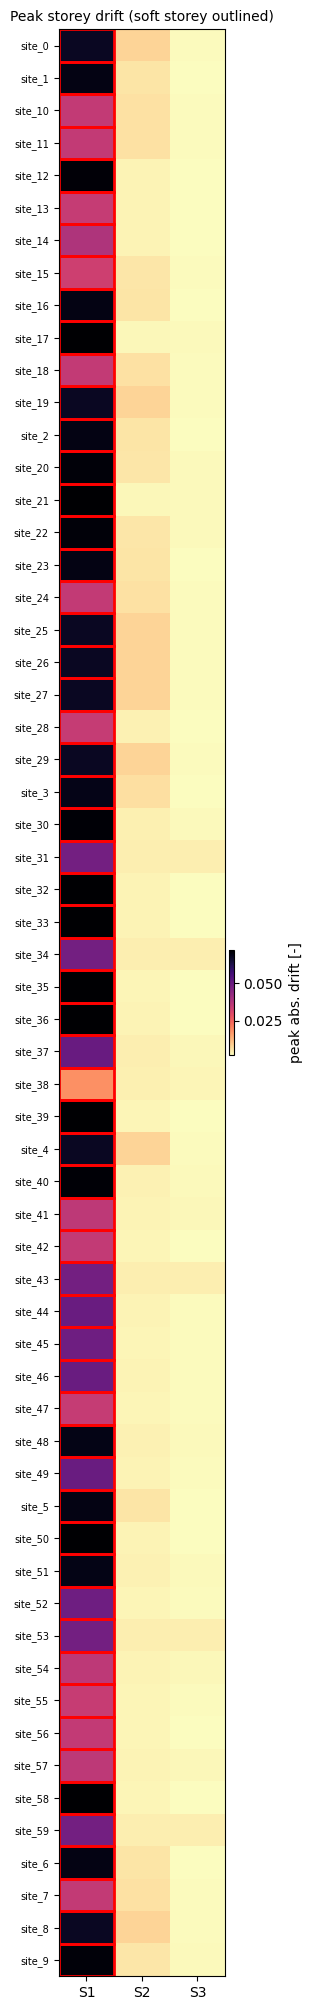

In [28]:
order = sorted(results, key=lambda t: (results[t]["n_storeys"], t))
max_s = max(r["n_storeys"] for r in results.values())
M = np.full((len(order), max_s), np.nan)
soft_cells = []
for i, tag in enumerate(order):
    r = results[tag]
    for s in range(1, r["n_storeys"] + 1):
        M[i, s - 1] = r["storey_peak_drift"].get(str(s), r["storey_peak_drift"].get(s, np.nan))
    for s in r["soft_storeys"]:
        soft_cells.append((i, s - 1))

fig, ax = plt.subplots(figsize=(1.0 + 0.7 * max_s, 0.32 * len(order) + 1))
im = ax.imshow(M, aspect="auto", cmap="magma_r")
ax.set_xticks(range(max_s))
ax.set_xticklabels([f"S{s}" for s in range(1, max_s + 1)])
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=7)
for (i, j) in soft_cells:               # outline the identified soft storey
    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec="r", lw=2))
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("peak abs. drift [-]")
ax.set_title("Peak storey drift (soft storey outlined)", fontsize=10)
fig.tight_layout()
plt.show()

## Create the New Soft Storey Models

In [ ]:
# --- analysis ---
DAMPING_RATIO = 0.05
MDOF_DRIFT_LIMIT = 0.2     # MDOF collapse drift limit

# --- cyclic pushover (FEMA 461) ---
CPO_U_MAX = 250          # mm, peak cyclic amplitude (+/-)
CPO_N_STEPS = 12         # FEMA 461 amplitude steps (12 -> matches example sequence)
CPO_DU = 0.1             # mm, base displacement ramp step (dU_max)
CPO_DISPLACEMENTS = np.round(
    np.append(FEMA_461_loading_protocol(CPO_U_MAX, CPO_N_STEPS), 0), 3
).tolist()

In [ ]:
def add_cyclic_pushover_files(folder: Path, ctrl_node: int) -> Path:
    """Add a FEMA 461 cyclic pushover run script + config to an analysis folder.
    The config imports structural_model/model_init from the folder itself."""
    copy_file(cfg["templates"]["run_cyclic_pushover"], folder / "run_cyclic_pushover.py")
    cfg_dst = folder / "config_cyclic_pushover.py"
    copy_analysis_config(
        cfg["templates"]["config_cyclic_pushover"],
        cfg_dst,
        results_folder_name="cyclic_pushover",
        update_config={
            "displacement_type": "displacement",
            "dU": CPO_DU,
            "ctrl_node": ctrl_node,
            "displacements": CPO_DISPLACEMENTS,
        },
    )
    return cfg_dst


def build_mdof_folder(site_idx: int) -> Path:
    tag = site_tag[site_idx]
    folder = DEST_ROOT / f"site_{site_idx}" / "mdof"
    folder.mkdir(parents=True, exist_ok=True)

    # design file (structural_model reads it from its own folder)
    design_out = Path(designs[tag]["design_out_json"])
    design_dst = folder / f"{tag}_designfile.json"
    copy_file(design_out, design_dst)

    # structural model
    n_damping_modes = get_n_damping_modes_from_design_file(design_dst)
    copy_structural_model(
        cfg["templates"]["structural_model"],
        folder / "structural_model.py",
        design_json=design_dst.name,
        damping_updates={"n_modes": n_damping_modes, "damping_ratio": DAMPING_RATIO},
        recorder_updates={"drift_limit": MDOF_DRIFT_LIMIT},
    )

    # modal analysis (for participation factor)
    copy_file(cfg["templates"]["run_modal"], folder / "run_modal.py")
    copy_analysis_config(
        cfg["templates"]["config_modal"],
        folder / "config_modal.py",
        results_folder_name="modal",
        update_config={"n_modes": get_n_primary_modes_from_design_file(design_dst)},
    )

    # cyclic pushover (FEMA 461)
    add_cyclic_pushover_files(folder, get_control_node_from_design_file(design_dst))
    return folder


mdof_folders = {ii: build_mdof_folder(ii) for ii in tqdm(
    [ii for ii in all_sites if designs[site_tag[ii]]["success"]],
    desc="Building MDOF folders")}
print(f"built {len(mdof_folders)} MDOF folders")